## Understanding Overfitting & Hyperparameter Tuning
Example on Penguins dataset

In [1]:
import pandas as pd

data = pd.read_csv("penguins.csv")
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [2]:
## Check missing values
data.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [3]:
data.dropna(inplace= True)
## Check missing values
data.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [5]:
#Setting the predictors and target

data.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [7]:
X = data[['bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g']]
y = data['species']

In [8]:
#Splitting Train and Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size= 0.2)

In [10]:
## Import and training Decision Treee classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [18]:
#Generalized model

simple_model = DecisionTreeClassifier(max_depth= 2, random_state= 42)
simple_model  = simple_model.fit(X_train, y_train)

print("Accuracy Simple Model Train:", accuracy_score(y_train, simple_model.predict(X_train)))
print("Accuracy Simple Model Test:", accuracy_score(y_test, simple_model.predict(X_test)))

Accuracy Simple Model Train: 0.9586466165413534
Accuracy Simple Model Test: 0.9850746268656716


In [13]:
#Overfitting model
overfit_model = DecisionTreeClassifier(max_depth= None, random_state= 42)
overfit_model  = overfit_model.fit(X_train, y_train)

print("Accuracy overfit Model Train:", accuracy_score(y_train, overfit_model.predict(X_train)))
print("Accuracy overfit Model Test:", accuracy_score(y_test, overfit_model.predict(X_test)))

Accuracy overfit Model Train: 1.0
Accuracy overfit Model Test: 1.0


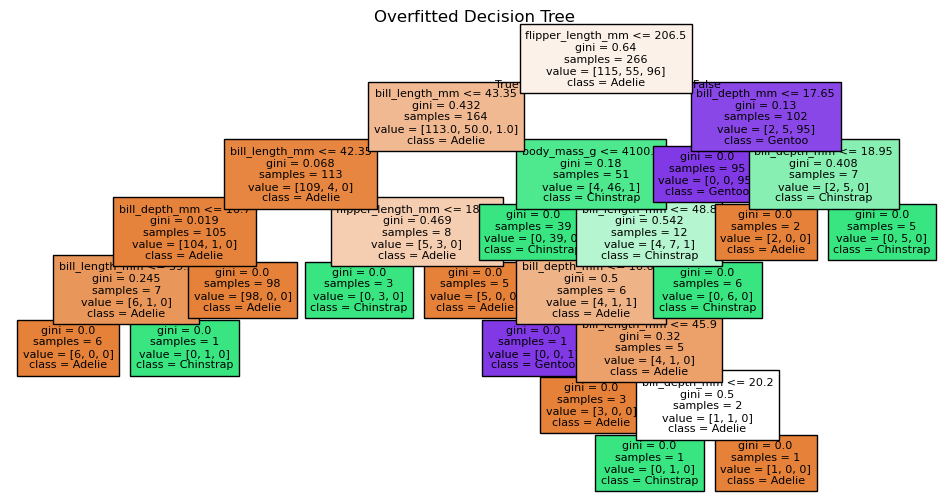

In [14]:
#Plotting of overtted tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
tree.plot_tree(
    overfit_model,
    feature_names=X.columns,
    class_names=overfit_model.classes_,
    filled=True,
    fontsize=8
)
plt.title("Overfitted Decision Tree")
plt.show()


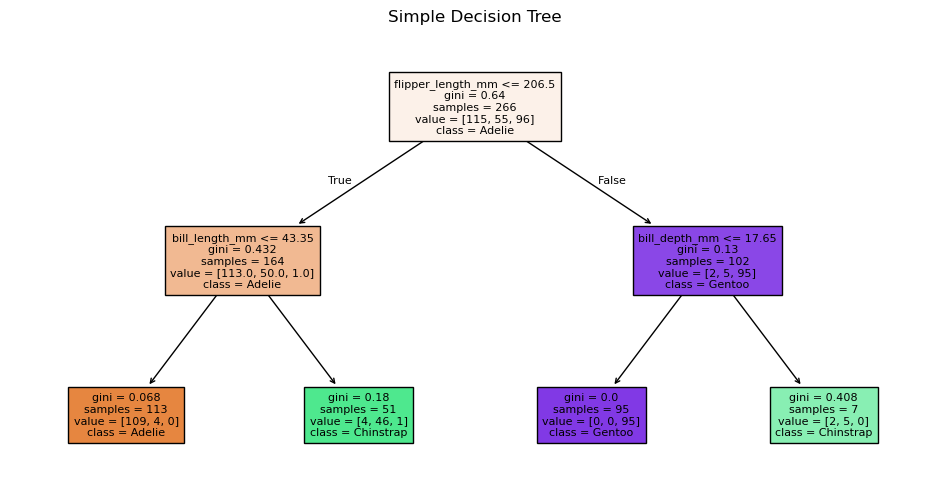

In [19]:
#Plotting of generalize tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
tree.plot_tree(
    simple_model,
    feature_names=X.columns,
    class_names=simple_model.classes_,
    filled=True,
    fontsize=8
)
plt.title("Simple Decision Tree")
plt.show()